In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from hetero_isas.zz_parallel_drive.hamiltonian import ZZ_ParallelDrive, NaiveCost
from matplotlib.widgets import Slider
from weylchamber import WeylChamber, c1c2c3
from numpy import random
from scipy.spatial import distance

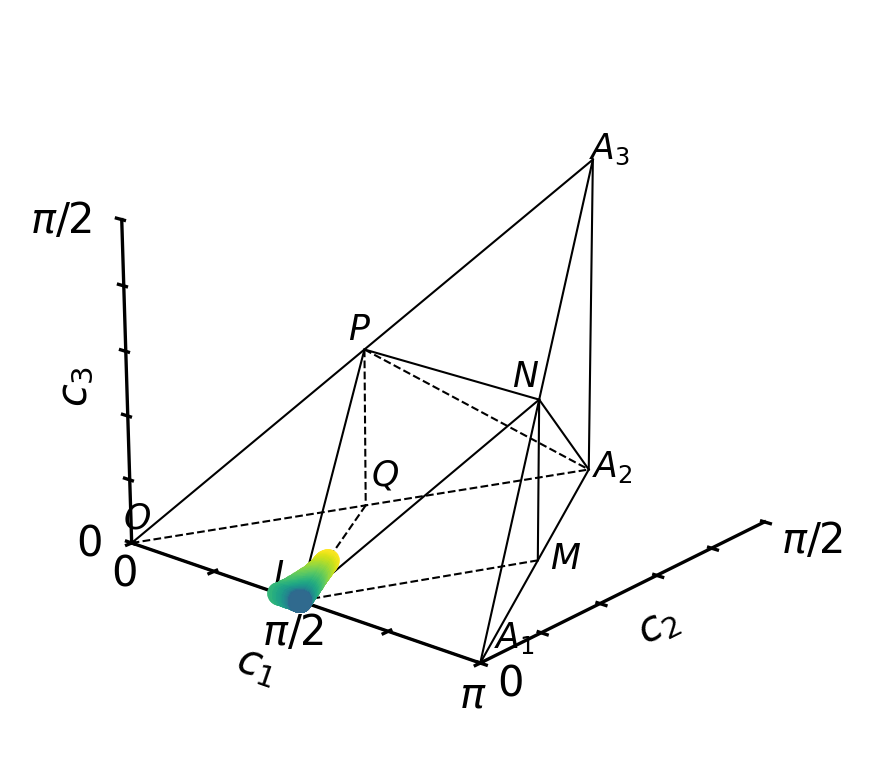

In [6]:
# random sampling of parameters
N = 5_000
coord_list = []
cost_list = []

g_vector = [0, 0, 0, 0, 0]
g_zz = np.pi / 2  # ZZ coefficient not subject to random sampling
gamma_max = np.pi / 2

for _ in range(N):
    g_rand = random.random(len(g_vector)) * 2 * gamma_max - gamma_max

    # NOTE, I am focing
    H = ZZ_ParallelDrive(g_zz, *g_rand[1:])
    U = H.to_unitary(t=1)
    c1, c2, c3 = c1c2c3(U)

    if True:  # optional eliminate y-axis symmetry
        if c1 > 0.5:
            c1 = 1 - c1

    coord_list.append((c1, c2, c3))
    cost_list.append(H.cost)

# pop point if there exists an immediate neighbor with less cost
# suggests the point was found with suboptimal parameter costs

coord_array = np.array(coord_list)
cost_array = np.array(cost_list)
D = distance.squareform(distance.pdist(coord_array))

if PRUNE := False:
    # set a distance threshold
    threshold = 0

    # create a mask to mark points for removal
    to_be_removed = np.zeros(len(coord_array), dtype=bool)

    # find neighbors within threshold
    for i in range(len(coord_array)):
        neighbors = D[i] < threshold
        neighbors[i] = False  # ignore self
        if np.any(cost_array[neighbors] < cost_array[i]):
            to_be_removed[i] = True

    # apply mask
    pruned_coord_array = coord_array[~to_be_removed]
    coord_list = list(pruned_coord_array)
    pruned_cost_array = cost_array[~to_be_removed]
    cost_list = list(pruned_cost_array)

# translate costs to colors
color_list = [NaiveCost.to_color(c, max_cost=max(cost_list)) for c in cost_list]

# plotting
w = WeylChamber()
for a, b in zip(coord_list, color_list):
    w.scatter(*a, color=b)
w.plot()

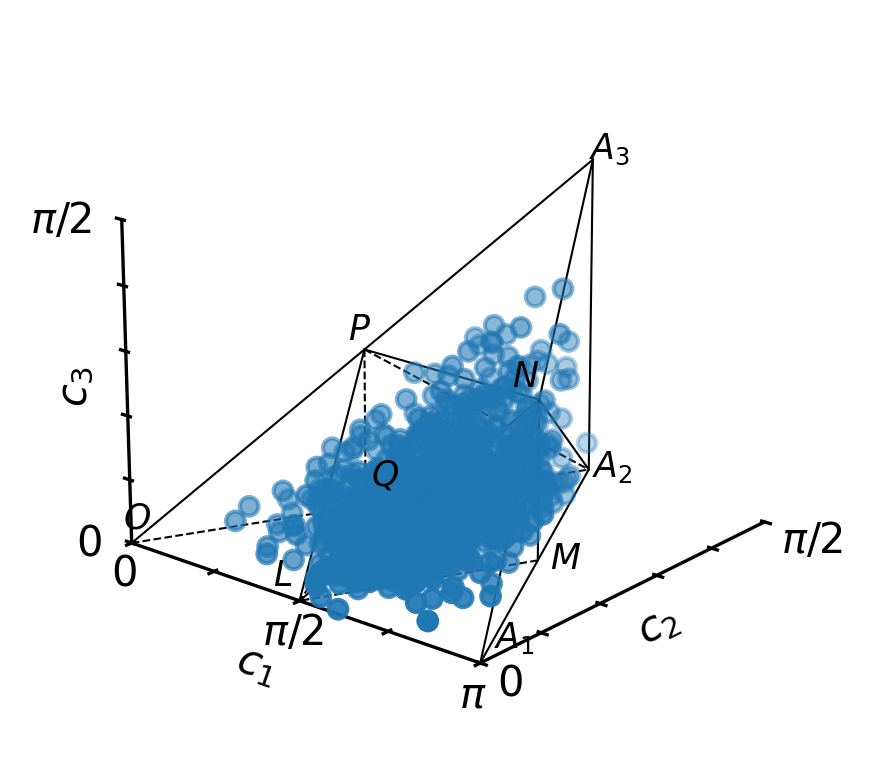

In [12]:
from qiskit import QuantumCircuit
from qiskit.circuit.library import iSwapGate, CXGate
from qiskit.circuit import Parameter
import numpy as np
from qiskit.quantum_info import Operator
from weylchamber import c1c2c3, WeylChamber

qc = QuantumCircuit(2)

qc.append(iSwapGate().power(1 / 2), [0, 1])

qc.u(Parameter("x1"), Parameter("x2"), Parameter("x3"), 0)
qc.u(Parameter("x4"), Parameter("x5"), Parameter("x6"), 1)
qc.append(iSwapGate().power(1 / 2), [0, 1])
qc.u(Parameter("x7"), Parameter("x8"), Parameter("x9"), 0)
qc.u(Parameter("xa"), Parameter("xb"), Parameter("xc"), 1)

qc.append(CXGate(), [0, 1])


p_list = []
for _ in range(1000):
    param_values = {
        param: np.random.uniform(-2 * np.pi, 2 * np.pi) for param in qc.parameters
    }
    temp_qc = qc.assign_parameters(param_values)
    p = c1c2c3(Operator(temp_qc).data)
    p_list.append(p)

w = WeylChamber()
w.scatter(*zip(*p_list))
w.plot()